# Colab 閱讀說明

這份 Notebook 是由 `EDA_統整_旅平險2023-2025.md` 轉寫而成，並已將主要圖表轉成靜態圖嵌入 Notebook。

因為原始 CSV 不會上傳到 Google Drive，本 Notebook 主要供閱讀與討論使用；圖表輸出已預先根據本機原始資料計算完成，Colab 開啟時不需要重新讀取資料。

# 旅平險 2023-2025 EDA 統整筆記

產出日期：2026-05-24  
原始資料：`2023-2025_旅平險_backup.csv`  
欄位定義：`2023-2025_旅平險_backup_各欄位定義.csv`  
地點對照：`旅遊地點代碼.csv`

# 靜態圖表總覽

以下圖表已經根據原始資料預先產生並嵌入 Notebook。上傳到 Google Drive 後，即使沒有原始 CSV，也能在 Colab 中查看。

## 靜態圖表：年度投保量與平均保費

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


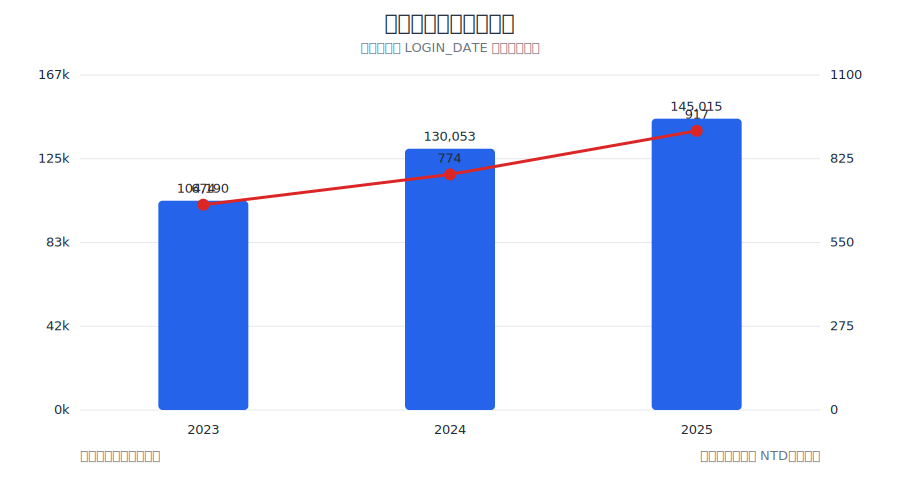

In [ ]:
# 靜態圖表：年度投保量與平均保費
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：月度投保量趨勢

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


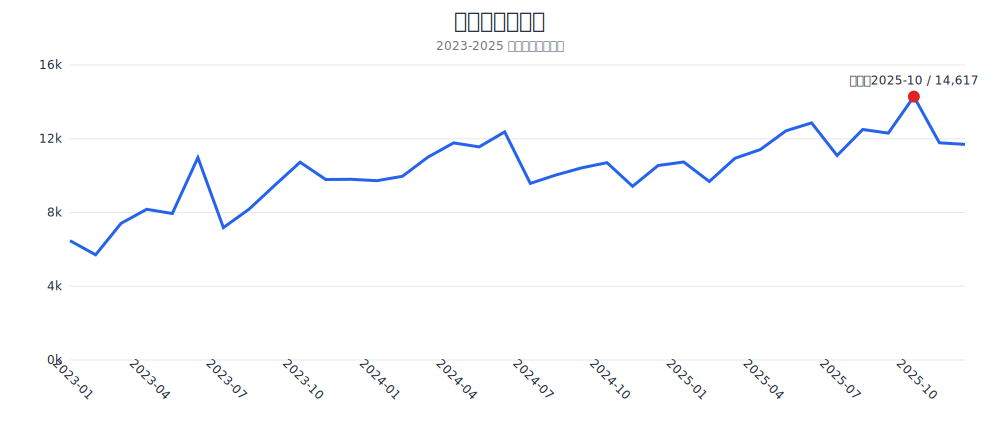

In [ ]:
# 靜態圖表：月度投保量趨勢
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：前 12 大旅遊地點

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


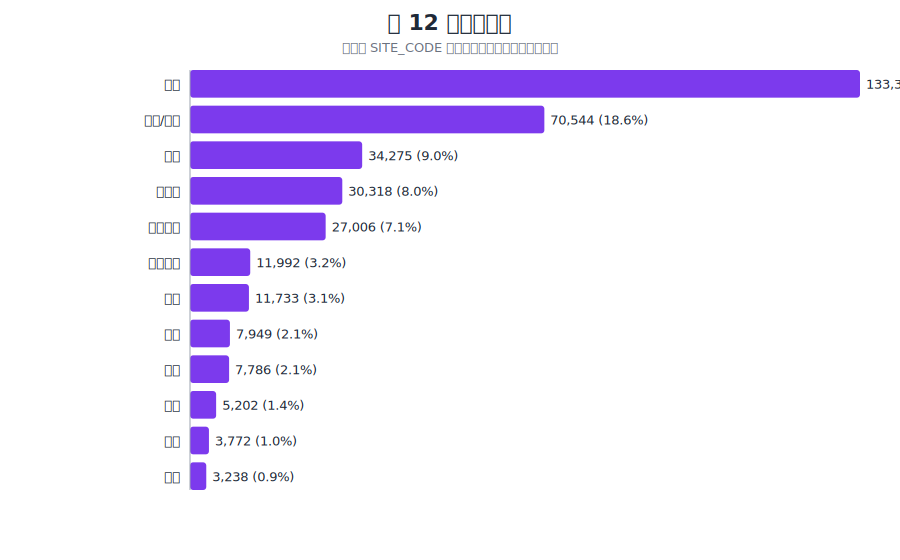

In [ ]:
# 靜態圖表：前 12 大旅遊地點
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：年齡分布

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


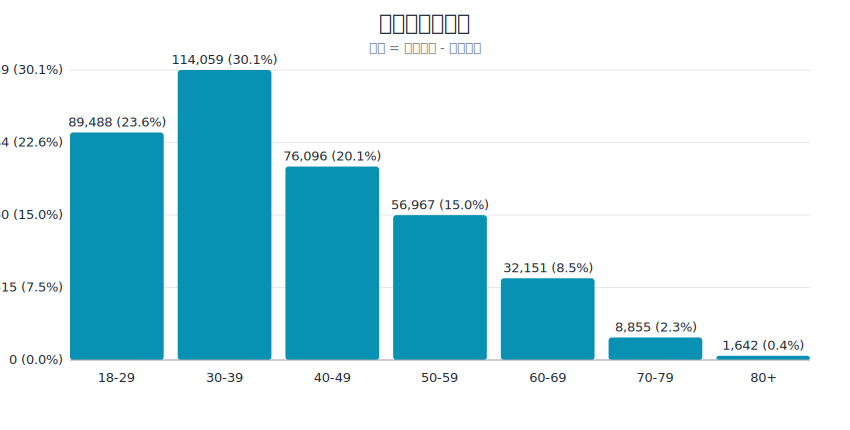

In [ ]:
# 靜態圖表：年齡分布
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：提前投保天數分布

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


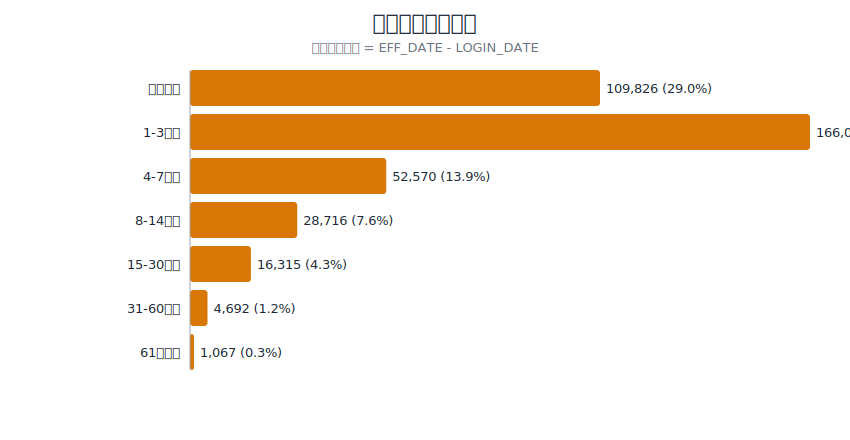

In [ ]:
# 靜態圖表：提前投保天數分布
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：保單效期分布

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


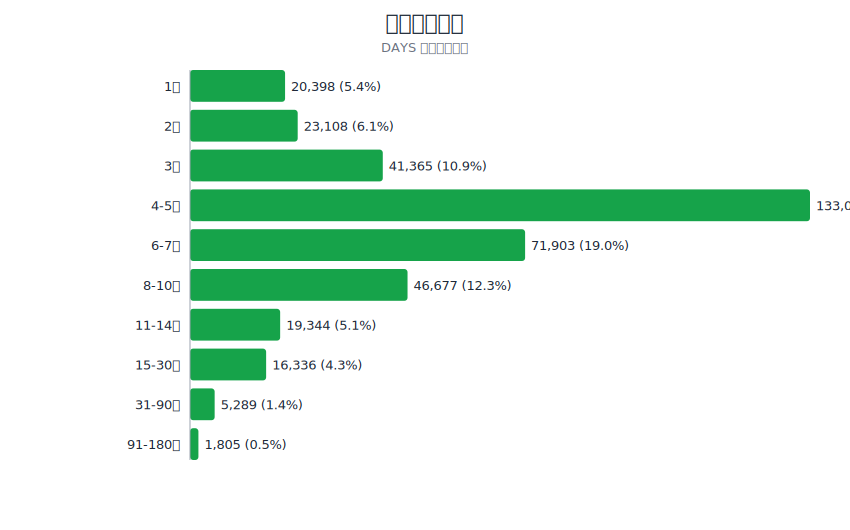

In [ ]:
# 靜態圖表：保單效期分布
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：保費分位數

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


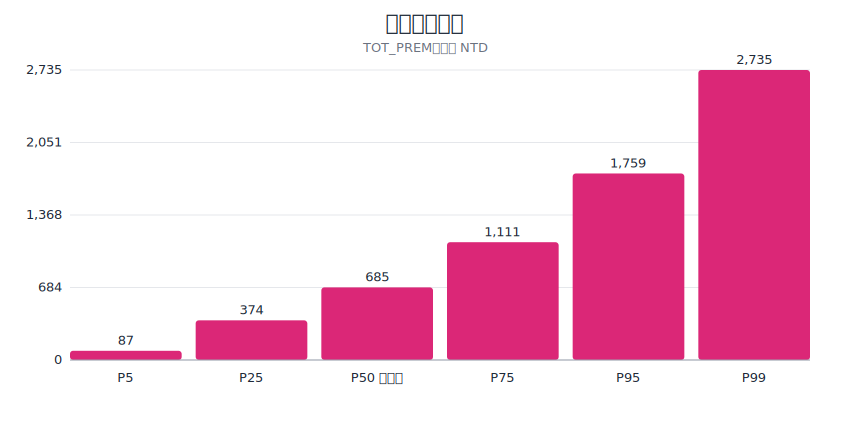

In [ ]:
# 靜態圖表：保費分位數
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 靜態圖表：付款方式分布

下方圖表已直接嵌入 Notebook，不需要讀取原始 CSV。


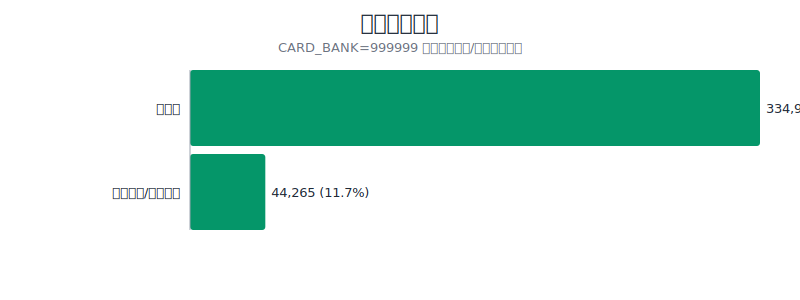

In [ ]:
# 靜態圖表：付款方式分布
# 圖表已預先由原始資料產生並嵌入輸出，不需重新執行。


## 1. 分析口徑說明

本文件整理目前已完成的描述統計與延伸 EDA，目標是讓後續寫期末報告或上台回答老師問題時，可以快速查到數字與背後口徑。

### 1.1 日期口徑

本資料有三個重要日期欄位：

| 欄位 | 中文意思 | 本分析用途 |
|---|---|---|
| `LOGIN_DATE` | 投保日期 | 客戶在官網完成投保/購買的日期，用來分析年度銷售與投保行為 |
| `EFF_DATE` | 生效起日 | 保單保障開始日，用來計算提前多久購買 |
| `CSTP_DATE` | 生效迄日 | 保單保障結束日，可輔助理解保單效期 |

年度趨勢以 `LOGIN_DATE` 為準，因為本研究關心的是「2023-2025 年在線上完成投保的行為」。  
若改用 `EFF_DATE`，分析問題會變成「保單在哪一年開始保障」，這比較接近旅程開始時間，不等於購買時間。

補充：原始資料的 `LOGIN_DATE` 範圍是 2023-01-01 至 2025-12-31，但 `EFF_DATE` 最晚到 2026-03-28。這是合理現象，因為客戶可能在 2025 年底先購買 2026 年初出發的旅平險。

### 1.2 客戶與回購口徑

本分析用 `APL_ID` 作為「投保者/客戶」的識別欄位。  
`NO` 是遮罩後的保單號，不適合作為唯一保單鍵，因此不應直接用 `NO` 判斷唯一保單。

回購的計算方式：

1. 以同一個 `APL_ID` 代表同一位投保者。
2. 將每位投保者的紀錄依 `LOGIN_DATE` 排序。
3. 每位投保者的第一筆視為初次投保。
4. 第一筆之後的紀錄視為回購/重複投保事件。
5. 回購週期 = 本次 `LOGIN_DATE` - 前一次 `LOGIN_DATE`。

年齡口徑：本文件用 `LOGIN_DATE` 所在年份減去 `APL_BIRTH` 出生年份，代表投保當下的大約年齡。

## 2. 資料整體概況

| 指標 | 結果 | 說明 |
|---|---:|---|
| 總保單紀錄數 | 379,258 | 原始資料列數 |
| 欄位數 | 12 | 原始資料欄位 |
| 投保者數 | 56,674 | 以 `APL_ID` 計算 |
| 缺失值 | 12 筆 | 只出現在 `SITE_CODE` |
| 缺失率 | 0.003% | 資料完整度非常高 |
| 多目的地 `SITE_CODE` | 19,125 筆 | 占 5.0%，如 `101141`、`131132` |
| `DAYS > 90` | 1,805 筆 | 占 0.48%，可能是長天期旅遊、交換、工作假期等 |
| `CARD_BANK = 999999` | 44,265 筆 | 占 11.7%，可視為非信用卡付款或特殊付款代碼 |

資料品質整體良好，主要需要注意的是 `SITE_CODE` 有多目的地串接，以及 `NO` 欄位已遮罩，不應拿來當唯一鍵。

## 3. 年度趨勢

年度統計以 `LOGIN_DATE` 投保日期為準。

| 年度 | 保單數 | 月平均 | YoY 成長 | 平均保費 | 平均投保天數 |
|---:|---:|---:|---:|---:|---:|
| 2023 | 104,190 | 8,683 | 基準年 | 674 | 7.5 |
| 2024 | 130,053 | 10,838 | +24.8% | 774 | 7.4 |
| 2025 | 145,015 | 12,085 | +11.5% | 917 | 7.2 |
| 合計/平均 | 379,258 | 10,535 | +39.2% | 801 | 7.4 |

解讀：保單量從 2023 到 2025 明顯增加，三年總成長約 39.2%。平均保費也從 674 元上升到 917 元，可能與保障額度、目的地組合或產品選擇變化有關。

季節性補充：2023、2024 的最高月份是 6 月，但 2025 的最高月份是 10 月。因此不宜說「每年都是 6 月最高」，比較保守的說法是「6 月在 2023、2024 明顯偏高，2025 則以 10 月最高」。

## 4. 重複投保與回購分析

### 4.1 重複投保者與無重複投保者

| 指標 | 數量 | 占比/說明 |
|---|---:|---|
| 總投保者數 | 56,674 人 | 以 `APL_ID` 計算 |
| 有重複投保者 | 44,053 人 | 占全部投保者 77.7% |
| 無重複投保者 | 12,621 人 | 占全部投保者 22.3% |
| 有重複投保者的全部保單紀錄 | 366,637 筆 | 包含第一筆與後續回購 |
| 扣除第一筆後的重複投保次數 | 322,584 次 | 這是「回購事件」總數 |

針對「無重複投保者」有兩種口徑：

| 口徑 | 結果 | 解釋 |
|---|---:|---|
| 未扣除第一筆投保紀錄 | 12,621 人，12,621 筆紀錄 | 這些人只投保過一次 |
| 扣除第一筆投保紀錄 | 12,621 人，0 筆回購事件 | 因為唯一的一筆就是第一筆，扣掉後沒有後續投保 |

簡報可用說法：資料中的投保者高度偏向重複使用，約 77.7% 的投保者在 2023-2025 期間不只投保一次。若扣除每位客戶的第一筆，後續回購事件共有 322,584 次。

### 4.2 每位投保者的投保次數分布

| 投保次數 | 人數 | 占投保者比例 |
|---|---:|---:|
| 1 次 | 12,621 | 22.3% |
| 2 次 | 7,087 | 12.5% |
| 3-5 次 | 14,026 | 24.7% |
| 6-10 次 | 12,374 | 21.8% |
| 11-20 次 | 7,153 | 12.6% |
| 21 次以上 | 3,413 | 6.0% |

解讀：這份資料不只是一次性客戶資料，裡面有大量高頻投保者。這可能代表旅平險具備明顯的重複購買特性，也可能包含家庭成員代買、固定商務旅行者、或經常出國族群。

### 4.3 有重複投保者的回購週期分布

回購週期以同一位投保者相鄰兩次 `LOGIN_DATE` 的間隔天數計算，共有 322,584 個回購間隔。

| 統計量 | 回購週期 |
|---|---:|
| 平均 | 94.4 天 |
| 25 百分位 | 19 天 |
| 中位數 | 51 天 |
| 75 百分位 | 120 天 |
| 90 百分位 | 238 天 |
| 95 百分位 | 344 天 |
| 99 百分位 | 595 天 |
| 最大值 | 1,070 天 |

| 回購週期區間 | 次數 | 占比 |
|---|---:|---:|
| 同日 | 4,486 | 1.4% |
| 1-7 天 | 31,187 | 9.7% |
| 8-30 天 | 79,548 | 24.7% |
| 31-90 天 | 101,927 | 31.6% |
| 91-180 天 | 56,552 | 17.5% |
| 181-365 天 | 35,056 | 10.9% |
| 366 天以上 | 13,828 | 4.3% |

解讀：回購週期中位數為 51 天，平均為 94.4 天，代表重複投保者多數不是一年才回來一次，而是在數週到數月內再次投保。31-90 天是最大區間，占 31.6%。

同日回購占 1.4%，可能是同一位使用者為不同旅程、不同被保人、或拆單情境完成多張投保。

## 5. 提前投保天數

提前投保天數 = `EFF_DATE` - `LOGIN_DATE`。  
這代表客戶在保單開始生效前多久，已先在官網完成投保。

| 統計量 | 提前投保天數 |
|---|---:|
| 平均 | 3.76 天 |
| 25 百分位 | 0 天 |
| 中位數 | 1 天 |
| 75 百分位 | 4 天 |
| 90 百分位 | 10 天 |
| 95 百分位 | 16 天 |
| 99 百分位 | 37 天 |
| 最大值 | 92 天 |

| 提前投保區間 | 保單數 | 占比 |
|---|---:|---:|
| 當天投保 | 109,826 | 29.0% |
| 1-3 天前 | 166,072 | 43.8% |
| 4-7 天前 | 52,570 | 13.9% |
| 8-14 天前 | 28,716 | 7.6% |
| 15-30 天前 | 16,315 | 4.3% |
| 31-60 天前 | 4,692 | 1.2% |
| 61 天以上 | 1,067 | 0.3% |

解讀：客戶普遍非常接近出發日才購買旅平險。約 72.7% 的保單是在生效前 3 天內購買，86.6% 在 7 天內購買。這對行銷或提醒策略很重要，代表臨近出發日前的提醒、旅遊平台合作、或付款流程順暢度，可能比很早期的廣告更直接影響轉換。

## 6. 保單效期與關聯因素

本節的保單效期以 `DAYS` 欄位表示。

### 6.1 保單效期整體分布

| 統計量 | 投保天數 |
|---|---:|
| 平均 | 7.36 天 |
| 5 百分位 | 1 天 |
| 25 百分位 | 4 天 |
| 中位數 | 5 天 |
| 75 百分位 | 7 天 |
| 90 百分位 | 11 天 |
| 95 百分位 | 16 天 |
| 99 百分位 | 56 天 |
| 最大值 | 180 天 |

| 天數區間 | 保單數 | 占比 |
|---|---:|---:|
| 1 天 | 20,398 | 5.4% |
| 2 天 | 23,108 | 6.1% |
| 3 天 | 41,365 | 10.9% |
| 4-5 天 | 133,033 | 35.1% |
| 6-7 天 | 71,903 | 19.0% |
| 8-10 天 | 46,677 | 12.3% |
| 11-14 天 | 19,344 | 5.1% |
| 15-21 天 | 11,376 | 3.0% |
| 22-30 天 | 4,960 | 1.3% |
| 31-60 天 | 3,717 | 1.0% |
| 61-90 天 | 1,572 | 0.4% |
| 91-180 天 | 1,805 | 0.5% |

解讀：旅平險最典型的保單效期是短天期旅遊，尤其 4-7 天合計占 54.1%。這很符合台灣常見的短假、週末加請假、或鄰近國家旅遊型態。

### 6.2 保單效期與旅遊地點

| 旅遊地點 | 保單數 | 平均天數 | 中位數 | 超過 14 天占比 | 平均保費 | 平均保額 |
|---|---:|---:|---:|---:|---:|---:|
| 日本 | 133,381 | 6.68 | 6 | 2.47% | 870 | 963 |
| 國內/台灣 | 70,544 | 3.02 | 3 | 1.18% | 250 | 718 |
| 南韓 | 34,275 | 5.57 | 5 | 1.01% | 779 | 940 |
| 東南亞 | 30,318 | 7.19 | 5 | 4.88% | 774 | 935 |
| 中國大陸 | 27,006 | 9.06 | 6 | 9.76% | 978 | 1,003 |
| 歐洲申根國家 | 11,992 | 15.19 | 11 | 27.56% | 1,413 | 1,110 |
| 香港 | 11,733 | 3.81 | 3 | 0.58% | 623 | 970 |
| 泰國 | 7,949 | 6.38 | 5 | 3.01% | 970 | 982 |
| 美國 | 7,786 | 22.12 | 13 | 43.17% | 1,496 | 1,143 |
| 越南 | 5,202 | 6.12 | 5 | 2.35% | 964 | 986 |
| 其他 | 3,772 | 12.21 | 10 | 15.72% | 1,067 | 1,040 |
| 澳門 | 3,238 | 3.51 | 3 | 0.37% | 585 | 972 |

解讀：旅遊地點與保單效期有明顯關係。國內、香港、澳門偏短；日本與南韓多為 5-6 天；歐美明顯較長，尤其美國平均 22.12 天，超過 14 天占比達 43.17%。

### 6.3 保單效期與年齡

| 年齡層 | 保單數 | 平均天數 | 中位數 | 超過 14 天占比 | 平均保費 |
|---|---:|---:|---:|---:|---:|
| 18-29 | 89,488 | 7.82 | 5 | 6.02% | 762 |
| 30-39 | 114,059 | 6.76 | 5 | 4.66% | 793 |
| 40-49 | 76,096 | 6.56 | 5 | 4.78% | 802 |
| 50-59 | 56,967 | 7.28 | 5 | 6.94% | 864 |
| 60-69 | 32,151 | 9.17 | 6 | 11.48% | 896 |
| 70-79 | 8,855 | 10.30 | 6 | 13.89% | 633 |
| 80+ | 1,642 | 11.16 | 6 | 13.22% | 279 |

解讀：年齡與保單天數有弱關聯，60 歲以上族群的平均旅遊天數較長。不過平均保費不是一路隨年齡上升，70 歲以上反而下降，可能與商品限制、可選保障方案或旅遊型態不同有關。

### 6.4 保單效期與保額/保費

| 保額分組 | 保單數 | 平均天數 | 中位數 | 超過 14 天占比 | 平均保費 |
|---|---:|---:|---:|---:|---:|
| 低保額 Q1 | 121,835 | 6.91 | 5 | 5.34% | 333 |
| 中低保額 Q2 | 72,291 | 7.94 | 5 | 6.98% | 714 |
| 中高保額 Q3 | 100,077 | 7.01 | 5 | 5.53% | 942 |
| 高保額 Q4 | 85,055 | 7.90 | 5 | 7.46% | 1,380 |

相關係數補充：

| 變數 | 與 `DAYS` 的 Pearson 相關 | 與 `DAYS` 的 Spearman 排名相關 | 解讀 |
|---|---:|---:|---|
| 年齡 | 0.029 | 0.077 | 很弱 |
| 保額 `TOT_SA` | 0.028 | 0.128 | 弱 |
| 保費 `TOT_PREM` | 0.582 | 0.594 | 中度偏強 |
| 提前投保天數 | 0.077 | 0.098 | 很弱 |

解讀：保單天數與保費有明顯關係，這符合保險定價直覺，保障天數越長通常保費越高。保額與天數的關聯較弱，表示保額高低不完全由旅遊天數決定，也可能受旅遊地點、年齡、方案選擇影響。

## 7. 有重複投保者的目的地與付款偏好

本節主要看「扣除第一筆後的回購事件」，共 322,584 次。

### 7.1 回購事件的旅遊地點分布

| 排名 | 旅遊地點 | 回購事件數 | 占回購事件比例 |
|---:|---|---:|---:|
| 1 | 日本 | 112,795 | 35.0% |
| 2 | 國內/台灣 | 58,987 | 18.3% |
| 3 | 南韓 | 29,733 | 9.2% |
| 4 | 東南亞 | 23,858 | 7.4% |
| 5 | 中國大陸 | 23,337 | 7.2% |
| 6 | 香港 | 10,550 | 3.3% |
| 7 | 歐洲申根國家 | 9,912 | 3.1% |
| 8 | 泰國 | 7,615 | 2.4% |
| 9 | 美國 | 6,522 | 2.0% |
| 10 | 越南 | 4,898 | 1.5% |
| 11 | 其他 | 3,156 | 1.0% |
| 12 | 澳門 | 2,917 | 0.9% |

解讀：回購事件的目的地分布與整體資料非常接近，日本仍是最大宗，占 35.0%。這表示日本不只是整體熱門目的地，也是在重複投保者中持續出現的核心目的地。

### 7.2 回購者是否固定選同一目的地

| 指標 | 結果 |
|---|---:|
| 與前一次投保完全相同 `SITE_CODE` 的回購事件 | 78,028 次 |
| 占所有回購事件比例 | 24.2% |

| 每位重複投保者出現過的不同目的地數 | 人數 | 占重複投保者比例 |
|---|---:|---:|
| 1 個 | 2,960 | 6.7% |
| 2 個 | 10,103 | 22.9% |
| 3 個 | 8,626 | 19.6% |
| 4 個 | 6,805 | 15.4% |
| 5 個 | 5,105 | 11.6% |
| 6 個 | 3,504 | 8.0% |
| 7 個 | 2,369 | 5.4% |
| 8 個 | 1,539 | 3.5% |
| 9 個 | 1,113 | 2.5% |
| 10 個 | 735 | 1.7% |
| 11 個以上 | 1,194 | 2.7% |

解讀：重複投保者不是只固定去同一個地方。只有 6.7% 的重複投保者在資料期間只出現 1 個目的地代碼，代表多數重複投保者具有跨目的地旅遊行為。

### 7.3 回購事件的信用卡/付款偏好

| 排名 | `CARD_BANK` | 回購事件數 | 占回購事件比例 |
|---:|---|---:|---:|
| 1 | 999999 | 41,861 | 13.0% |
| 2 | 356969 | 23,250 | 7.2% |
| 3 | 524108 | 18,884 | 5.9% |
| 4 | 414763 | 14,623 | 4.5% |
| 5 | 428430 | 12,194 | 3.8% |
| 6 | 418230 | 10,767 | 3.3% |
| 7 | 447757 | 10,625 | 3.3% |
| 8 | 540805 | 7,818 | 2.4% |
| 9 | 524255 | 7,311 | 2.3% |
| 10 | 470538 | 7,254 | 2.2% |
| 11 | 430451 | 6,705 | 2.1% |
| 12 | 515721 | 6,242 | 1.9% |

補充指標：

| 指標 | 結果 |
|---|---:|
| 回購事件中 `CARD_BANK = 999999` | 41,861 次，占 13.0% |
| 整體資料中 `CARD_BANK = 999999` | 44,265 次，占 11.7% |
| 回購事件與前一次使用相同 `CARD_BANK` | 59,311 次，占 18.4% |

解讀：回購事件中非信用卡/特殊付款代碼 `999999` 的占比為 13.0%，略高於整體資料的 11.7%。回購者不一定固定使用同一張卡或同一銀行代碼，與前一次相同 `CARD_BANK` 的比例只有 18.4%。

## 8. 投保者樣態分布

### 8.1 年齡分布

| 年齡層 | 保單數 | 占比 |
|---|---:|---:|
| 18-29 | 89,488 | 23.6% |
| 30-39 | 114,059 | 30.1% |
| 40-49 | 76,096 | 20.1% |
| 50-59 | 56,967 | 15.0% |
| 60-69 | 32,151 | 8.5% |
| 70-79 | 8,855 | 2.3% |
| 80+ | 1,642 | 0.4% |

解讀：30-39 歲是最大族群，占 30.1%；18-49 歲合計約 73.8%，代表線上旅平險主力客群偏向青壯年與中壯年。

### 8.2 旅遊地點分布

| 排名 | 旅遊地點 | 保單數 | 占比 |
|---:|---|---:|---:|
| 1 | 日本 | 133,381 | 35.2% |
| 2 | 國內/台灣 | 70,544 | 18.6% |
| 3 | 南韓 | 34,275 | 9.0% |
| 4 | 東南亞 | 30,318 | 8.0% |
| 5 | 中國大陸 | 27,006 | 7.1% |
| 6 | 歐洲申根國家 | 11,992 | 3.2% |
| 7 | 香港 | 11,733 | 3.1% |
| 8 | 泰國 | 7,949 | 2.1% |
| 9 | 美國 | 7,786 | 2.1% |
| 10 | 越南 | 5,202 | 1.4% |
| 11 | 其他 | 3,772 | 1.0% |
| 12 | 澳門 | 3,238 | 0.9% |
| 13 | 澳大利亞 | 3,067 | 0.8% |
| 14 | 多目的地/未對照 `101141` | 2,067 | 0.5% |
| 15 | 馬來西亞 | 1,732 | 0.5% |

解讀：日本是壓倒性的第一大目的地，占 35.2%。若加上國內/台灣、南韓、東南亞與中國大陸，前五大目的地已占約 77.9%，目的地集中度相當高。

### 8.3 信用卡/付款分布

`CARD_BANK` 欄位疑似為信用卡 BIN/IIN 前 6 碼，可透過公開第三方 BIN 查詢資料庫推估發卡銀行。不過官方完整 IIN register 通常不是一般公開資料，且第三方資料可能有更新落差或銀行併購後未同步的問題，因此下表的銀行名稱只作為輔助對照，正確性仍待富邦人壽內部欄位定義或官方資料確認。`999999` 不屬於一般信用卡 BIN，應視為資料內部定義的非信用卡或特殊付款代碼。

| 排名 | `CARD_BANK` | 公開查詢推估銀行/付款類型 | 保單數 | 占比 |
|---:|---|---|---:|---:|
| 1 | 999999 | 非信用卡/特殊付款代碼，待內部定義確認 | 44,265 | 11.7% |
| 2 | 356969 | 台北富邦銀行，待確認 | 27,541 | 7.3% |
| 3 | 524108 | 台北富邦銀行，待確認 | 21,820 | 5.8% |
| 4 | 414763 | 台新銀行，待確認 | 17,279 | 4.6% |
| 5 | 428430 | 國泰世華銀行，待確認 | 14,262 | 3.8% |
| 6 | 447757 | 中國信託/CTBC，待確認 | 12,960 | 3.4% |
| 7 | 418230 | 中國信託/CTBC，待確認 | 12,817 | 3.4% |
| 8 | 540805 | 花旗台灣或星展台灣，公開資料不一致，待確認 | 9,150 | 2.4% |
| 9 | 470538 | 中華郵政，待確認 | 9,052 | 2.4% |
| 10 | 524255 | 玉山銀行，待確認 | 8,807 | 2.3% |
| 11 | 430451 | 中國信託/CTBC，待確認 | 7,693 | 2.0% |
| 12 | 515721 | 台新銀行，待確認 | 7,143 | 1.9% |

公開查詢來源註記：可用 [Binlist](https://binlist.io/)、[BIN Database](https://www.bindatabase.net/)、[Bincheck](https://bincheck.io/)、[Check-BIN](https://check-bin.com/) 等第三方工具查詢。但這些來源不是保險公司內部資料字典，也不是完整官方 IIN register，因此報告中建議使用「公開 BIN 查詢推估」而非「確定為」。

付款方式概況：

| 付款類型 | 保單數 | 占比 | 平均保費 | 平均天數 |
|---|---:|---:|---:|---:|
| 信用卡 | 334,993 | 88.3% | 794 | 7.4 |
| 非信用卡/特殊付款 `999999` | 44,265 | 11.7% | 852 | 6.6 |

解讀：信用卡仍是主要付款方式，占 88.3%。但 `999999` 這類非信用卡或特殊付款代碼占 11.7%，且平均保費略高，值得在後續分群分析中獨立觀察。

## 9. 保額與保費描述統計

### 9.1 總保額 `TOT_SA`

欄位單位依原 EDA 標示為「NTD 萬」。

| 統計量 | 數值 |
|---|---:|
| 最小值 | 21 |
| 5 百分位 | 203 |
| 25 百分位 | 600 |
| 中位數 | 960 |
| 平均 | 933 |
| 75 百分位 | 1,296 |
| 95 百分位 | 1,650 |
| 99 百分位 | 1,801 |
| 最大值 | 7,201 |
| 標準差 | 490 |

### 9.2 總保費 `TOT_PREM`

| 統計量 | 數值 |
|---|---:|
| 最小值 | 6 |
| 5 百分位 | 87 |
| 25 百分位 | 374 |
| 中位數 | 685 |
| 平均 | 801 |
| 75 百分位 | 1,111 |
| 95 百分位 | 1,759 |
| 99 百分位 | 2,735 |
| 最大值 | 9,888 |
| 標準差 | 610 |

解讀：保費與保額皆呈現右偏分布，平均數高於中位數，表示少數高保額或長天期保單把平均拉高。保費 99 百分位為 2,735 元，可作為高保費異常或高價值保單的參考門檻。

注意：若 `TOT_SA` 的單位確實是「萬元」，則中位保費 685 元 / 中位保額 960 萬元的比例約為 0.007%，不是 0.07%。原 EDA 報告中這句建議修正。

## 10. 目前最重要的結論

1. 這份資料非常適合做期末報告，因為筆數大、缺失率低，且有清楚的時間、目的地、保費、保額與付款資訊。
2. 年度趨勢應用 `LOGIN_DATE`，因為研究重點是線上投保行為，不是保障生效年度。
3. 投保者高度重複使用，56,674 位投保者中有 44,053 位重複投保，占 77.7%。
4. 扣掉每位投保者第一筆後，回購事件共有 322,584 次，回購週期中位數為 51 天。
5. 客戶多半很接近生效日前才購買，72.7% 在生效前 3 天內完成投保。
6. 保單效期以 4-7 天最常見，占 54.1%，符合短期旅遊情境。
7. 旅遊地點與保單天數關係明顯，美國、歐洲申根國家的保單天數較長，國內、香港、澳門較短。
8. 日本是最核心目的地，整體占 35.2%，回購事件也占 35.0%。
9. 信用卡是主要付款方式，占 88.3%；但 `999999` 仍占 11.7%，且在回購事件中占比升至 13.0%。
10. 30-39 歲是最大年齡層，占 30.1%；18-49 歲合計約 73.8%，是線上旅平險主力族群。

## 11. 後續可延伸分析方向

1. 客戶分群：依投保頻率、目的地、保費、天數分成高頻短途型、長途高保費型、國內短天期型等。
2. 回購預測：用前次目的地、前次保費、回購週期、年齡層預測是否會再次投保。
3. 目的地變化路徑：分析重複投保者是否從國內/亞洲短途逐漸轉向歐美長途。
4. 付款方式分群：比較信用卡與 `999999` 族群在保費、天數、目的地上的差異。
5. 提前投保行為：分析哪些目的地或年齡層會更早購買，作為行銷提醒時機依據。